<a href="https://colab.research.google.com/github/ongsoony8382/financial-data-programming/blob/main/Scikit_learn%EB%9D%BC%EC%9D%B4%EB%B8%8C%EB%9F%AC%EB%A6%AC%2C_%ED%9A%8C%EA%B7%80%EB%AA%A8%EB%8D%B8ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 금융데이터 분석(3): 7주차 동영상수업

# 학습목표
- 기계학습(machine learing)
- 인공지능 모델 구축 (AI Model)

# 학습내용
- 기계학습(machine learing) 코딩 연습
- AI모델구축, AI학습, AI모델평가 코딩 연습
- 건강상태와 생활습관 정보를 이용한 건강보험 보험료 산출
- Scikit-learn 라이브러리, 회귀(Regression) 모델


# 데이터 전처리 (Preprocessing)
머신러닝 모델은 수학적인 계산을 수행하므로, '성별(sex)', '흡연여부(smoker)' 같은 글자 데이터를 숫자로 바꿔주어야 함.

## 데이터 로드 및 인코딩

In [2]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# 데이터 로드
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

# 1. 범주형 데이터(문자열)를 수치형으로 변환 (One-Hot Encoding)
# pd.get_dummies: 문자로 된 컬럼을 0과 1로 변환해주는 함수 (성별, 흡연여부 등)
df_encoded = pd.get_dummies(df, drop_first=True)

print("인코딩 전 컬럼:", df.columns.tolist())
print("인코딩 후 컬럼:", df_encoded.columns.tolist())

# 변환된 데이터 확인 (sex_male, smoker_yes 등으로 변경됨)
df_encoded.head()

인코딩 전 컬럼: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']
인코딩 후 컬럼: ['age', 'bmi', 'children', 'charges', 'sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']


,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [3]:
df_encoded.tail()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1333,50,30.97,3,10600.5483,True,False,True,False,False
1334,18,31.92,0,2205.9808,False,False,False,False,False
1335,18,36.85,0,1629.8335,False,False,False,True,False
1336,21,25.80,0,2007.9450,False,False,False,False,True
1337,61,29.07,0,29141.3603,False,True,True,False,False


# 학습용 데이터와 평가용 데이터 분리
- 모델이 정답을 외우지 않고 학습할 수 있도록 데이터를 분리(spliting).

- X (문제지): 나이, BMI, 자녀 수, 흡연 여부 등
- y (정답지): 보험료(charges)
- 학습을 위한 데이터와 테스트를 위한 데이터를 구분(slicing)

In [4]:
# X(특성)와 y(타겟) 분리
X = df_encoded.drop('charges', axis=1) # 정답 컬럼 제외
y = df_encoded['charges']              # 정답 컬럼만 선택


학습용 데이터 개수: (936, 8)
테스트용 데이터 개수: (402, 8)
학습용 정답 데이터 개수: (936,)
테스트용 정답 데이터 개수: (402,)


In [5]:
X.tail()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1333,50,30.97,3,True,False,True,False,False
1334,18,31.92,0,False,False,False,False,False
1335,18,36.85,0,False,False,False,True,False
1336,21,25.80,0,False,False,False,False,True
1337,61,29.07,0,False,True,True,False,False


In [7]:
y.tail()

,charges
1333,10600.5483
1334,2205.9808
1335,1629.8335
1336,2007.9450
1337,29141.3603


In [10]:
# 학습 세트(70%)와 테스트 세트(30%)로 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"학습용 데이터 개수: {X_train.shape}")
print(f"테스트용 데이터 개수: {X_test.shape}")

print(f"학습용 정답 데이터 개수: {y_train.shape}")
print(f"테스트용 정답 데이터 개수: {y_test.shape}")

학습용 데이터 개수: (936, 8)
테스트용 데이터 개수: (402, 8)
학습용 정답 데이터 개수: (936,)
테스트용 정답 데이터 개수: (402,)


In [9]:
X_train.tail()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1095,18,31.350,4,False,False,False,False,False
1130,39,23.870,5,False,False,False,True,False
1294,58,25.175,0,True,False,False,False,False
860,37,47.600,2,False,True,False,False,True
1126,55,29.900,0,True,False,False,False,True


# 인공지능 모델 학습 1 (AI Model Training 1)
- 가장 기본적이면서도 설명력이 좋은 선형 회귀(Linear Regression) 모델을 사용

In [12]:
# 모델 생성
model = LinearRegression()

# 모델 학습 (공부 시작)
model.fit(X_train, y_train)

print("모델 학습 완료!")
print(f"회귀계수(가중치): {model.coef_}") # 각 항목이 보험료에 미치는 영향
print(f"절편(기본값): {model.intercept_}")

모델 학습 완료!
회귀계수(가중치): [  261.29692414   348.90691516   424.11912829   104.81182299
 23628.36722236  -486.93461047  -970.96883857  -926.32290791]
절편(기본값): -12373.963903035481



# 모델 평가 (Model Evaluation)
- 학습하지 않은 데이터(Test Set)를 주었을 때 얼마나 잘 맞히는지 확인

In [13]:
# 예측 수행
y_pred = model.predict(X_test)

# 평가 (R-squared 점수: 1에 가까울수록 좋음)
score = r2_score(y_test, y_pred)
print(f"모델 정확도(R^2 Score): {score:.4f}")


모델 정확도(R^2 Score): 0.7696


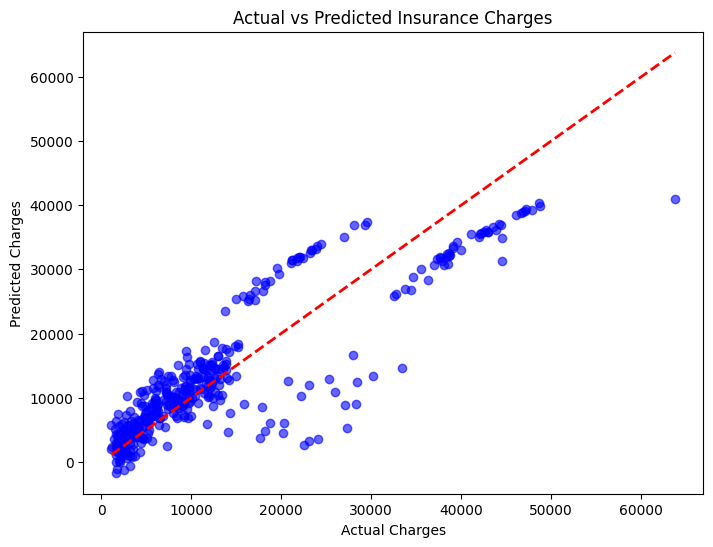

In [14]:
# 시각화로 확인하기 (실제값 vs 예측값)
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='b')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # 기준선
plt.xlabel('Actual Charges')
plt.ylabel('Predicted Charges')
plt.title('Actual vs Predicted Insurance Charges')
plt.show()


# 모델 실제 사용: 신규 보험계약자의 보험료 예측 (Prediction)
아래의 시나리오로 가상의 인물을 설정하여 보험료를 예측해 봅니다.

- 나이: 35세
- BMI: 28 (과체중)
- 자녀: 2명
- 성별: 남성 (sex_male = 1)
- 흡연: 안함 (smoker_yes = 0)
- 지역: 북서쪽 (region_northwest = 1, 나머지는 0)

In [19]:
# 1. 신규 고객 데이터 생성 (학습 데이터와 같은 컬럼 순서여야 함)
new_customer = {
    'age': 35,
    'bmi': 28,
    'children': 2,
    'sex_male': 1,         # 남성
    'smoker_yes': 0,       # 비흡연
    'region_northwest': 1, # 거주지
    'region_southeast': 0,
    'region_southwest': 0
}

# DataFrame으로 변환
new_df = pd.DataFrame([new_customer])

# 2. 모델을 통한 예측
predicted_charge = model.predict(new_df)

print(f"이 신규 고객의 예상 보험료는 약 ${predicted_charge[0]:,.2f}입니다.")


이 신규 고객의 예상 보험료는 약 $7,006.94입니다.


# 인공지능 모델 학습 2 (AI Model Training 2)

- 선형 회귀는 단순해서 정확도(77%)가 크게 높지 않음.
- 최근 기계학습 도구로 자주 사용되는 모델인 랜덤포레스트(Random Forest)를 이용하여 모델 학습을 개선

In [22]:
from sklearn.ensemble import RandomForestRegressor

# 더 강력한 모델 사용
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 성능 확인
rf_score = rf_model.score(X_test, y_test)
print(f"랜덤 포레스트 모델 정확도: {rf_score:.4f}")
# (보통 85% 이상으로 성능이 향상됩)

랜덤 포레스트 모델 정확도: 0.8521
